# Demo 02 : Differences between models

Two models, one document, one prompt. Compare what they cost, how long they
take, and whether they get the answer right.

The document is a shareholder list where some rows are struck through, meaning
the allocation was cancelled. Reading it correctly needs the model to notice
that and drop those rows. A smaller model often does not.

Run the next cell first. In Colab, add the course key under the key
icon in the left sidebar as `COURSE_API_KEY`, with *Notebook access* on.

In [ ]:
# Course setup. In Colab: add the course key under the key icon (left sidebar)
# as COURSE_API_KEY. On your own machine it uses Ollama instead.
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Pinned, including the transitive ones. Unpinned, pip takes whatever
    # shipped this morning : a newer core moves ModelError, and a newer openai
    # rejects this endpoint's usage payload. Keep in step with requirements.txt.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "langchain==1.3.9", "langchain-core==1.4.7",
                    "langchain-openai==1.3.2", "langchain-classic==1.0.8",
                    "langgraph==1.2.5", "openai==2.41.1", "python-dotenv"],
                   check=True)
    MODEL = "qwen3.8-flash"          # try qwen3.8-max too
    BASE = "https://token-plan.ap-southeast-1.maas.aliyuncs.com/compatible-mode/v1"
    THINKING = {"enable_thinking": False}
    KEY = os.getenv("COURSE_API_KEY")
    if not KEY:
        try:
            from google.colab import userdata
            KEY = userdata.get("COURSE_API_KEY")   # raises if unset or not shared
        except Exception:
            import getpass
            KEY = getpass.getpass("Course key (paste the one from the trainer): ")
else:
    from dotenv import load_dotenv
    load_dotenv()
    MODEL = "qwen3.5:2b"             # try qwen3.5:4b too
    BASE = "http://localhost:11434/v1"
    KEY = "ollama"
    THINKING = {"reasoning_effort": "none"}

from langchain_openai import ChatOpenAI


def make_llm(**kw):
    kw.setdefault("temperature", 0)
    kw.setdefault("model", MODEL)
    kw.setdefault("extra_body", THINKING)
    return ChatOpenAI(base_url=BASE, api_key=KEY, **kw)


def make_embeddings(**kw):
    # The course endpoint has no embeddings, so they run here instead. 90 MB,
    # installed only by the notebooks that actually ask for them.
    try:
        from langchain_huggingface import HuggingFaceEmbeddings
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "langchain-huggingface==0.3.1"], check=True)
        from langchain_huggingface import HuggingFaceEmbeddings
    kw.setdefault("model_name", "sentence-transformers/all-MiniLM-L6-v2")
    return HuggingFaceEmbeddings(**kw)


DATA_URL = ("https://raw.githubusercontent.com/FeikoWielsma/"
            "Building-AI-Agents/main/data/")


def data(name):
    """Path to a course data file. Downloads it in Colab, local copy otherwise."""
    if os.path.exists(f"../data/{name}"):
        return f"../data/{name}"
    if not os.path.exists(name):
        import urllib.request
        urllib.request.urlretrieve(DATA_URL + name, name)
    return name


llm = make_llm()
print(f"model={MODEL}")

In [ ]:
%pip install -q pandas matplotlib

### The two models to compare

The pair depends on the provider. Locally it is the classroom default against
the next size up; the point is the same either way.

In [ ]:
# A small fast model against a bigger one, on the same task.
COMPARE = ["qwen3.8-flash", "qwen3.8-max"] if IN_COLAB else ["qwen3.5:2b", "qwen3.5:4b"]

print("comparing", COMPARE[0], "against", COMPARE[1])

### The document and the prompt

In [4]:
import json
import time

import pandas as pd

with open(data("document.md"), encoding="utf-8") as fh:
    document_text = fh.read()

system_prompt = (
    "You are an intelligent assistant analyzing company shareholder information. "
    "You will be provided with a document containing shareholder data. "
    "Rows that are crossed out or cancelled are NOT current shareholders; exclude them. "
    "Respond with ONLY JSON, a list of objects with the keys shareholder_name, "
    "birthdate, share_amount. No markdown, no extra text."
)

question = ("Document:\n\n" + document_text
            + "\n\nWhat are the current shareholders of this company?")


def parse_json(text):
    """Tolerate models that wrap their JSON in a fence."""
    t = text.strip()
    if t.startswith("```"):
        t = t.split("```")[1]
        if t.lstrip().lower().startswith("json"):
            t = t.lstrip()[4:]
    return json.loads(t)


print(f"{len(document_text)} characters of document")

1311 characters of document


### Run the same prompt against both

`make_llm(model=...)` overrides only the model name; everything else about the
connection stays as the provider switch set it.

In [5]:
runs = {}

for name in COMPARE:
    model = make_llm(model=name)
    start = time.time()
    response = model.invoke([
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": question},
    ])
    runs[name] = {"seconds": round(time.time() - start, 1),
                  "usage": response.usage_metadata,
                  "content": response.content}
    print(f"{name:14} {runs[name]['seconds']:6.1f}s  {runs[name]['usage']}")

qwen3.5:2b        3.3s  {'input_tokens': 637, 'output_tokens': 86, 'total_tokens': 723, 'input_token_details': {}, 'output_token_details': {}}


qwen3.5:4b       17.4s  {'input_tokens': 637, 'output_tokens': 83, 'total_tokens': 720, 'input_token_details': {}, 'output_token_details': {}}


### What it cost

`input_tokens` is nearly identical because both models read the same document.
The interesting columns are `output_tokens` and the wall clock.

In [6]:
comparison = pd.DataFrame([
    {
        "seconds": r["seconds"],
        "input_tokens": r["usage"]["input_tokens"],
        "output_tokens": r["usage"]["output_tokens"],
        "total_tokens": r["usage"]["total_tokens"],
    }
    for r in runs.values()
], index=list(runs))

comparison

,seconds,input_tokens,output_tokens,total_tokens
qwen3.5:2b,3.3,637,86,723
qwen3.5:4b,17.4,637,83,720


<Axes: >

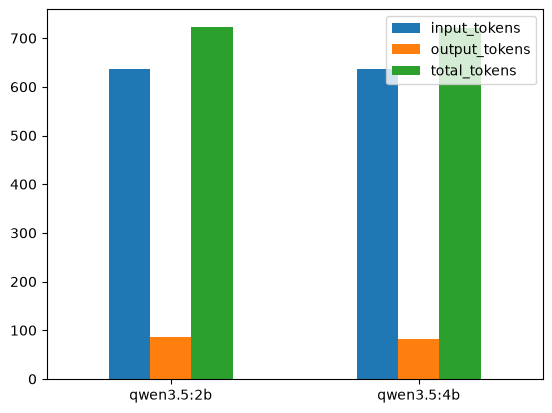

In [7]:
comparison[["input_tokens", "output_tokens", "total_tokens"]].plot.bar(rot=0)

<Axes: >

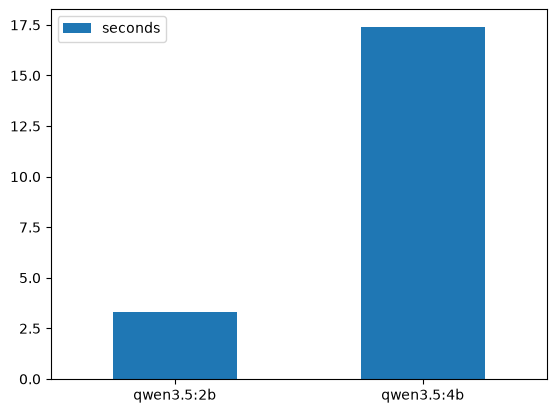

In [8]:
comparison[["seconds"]].plot.bar(rot=0)

### Did they get it right

There are two current shareholders totalling 25.000,00 EUR. Three rows are
struck through and must be dropped. A model that returns five rows read the
table but not the notation.

In [9]:
for name, run in runs.items():
    print("=" * 60)
    print(name)
    try:
        rows = parse_json(run["content"])
        print(pd.DataFrame(rows).to_string(index=False))
        print(f"-> {len(rows)} shareholders returned, 2 expected")
    except Exception as exc:
        print(f"could not parse the answer as JSON: {type(exc).__name__}: {exc}")
        print(run["content"][:300])

qwen3.5:2b
   shareholder_name  birthdate share_amount
       Jan Kowalski 30.09.1955     20000.00
Zdzisław Malinowski 28.07.1976      5000.00
-> 2 shareholders returned, 2 expected
qwen3.5:4b
   shareholder_name  birthdate  share_amount
       Jan Kowalski 30.09.1955       20000.0
Zdzisław Malinowski 28.07.1976        5000.0
-> 2 shareholders returned, 2 expected


### What this shows

Cost, latency and accuracy do not move together. On the run committed here both
models returned the same two shareholders and the larger one took five times as
long, so the extra size bought nothing on this task. Re-run it and the numbers
will differ; the shape usually will not.

That is the argument for orchestration from module 01. Pick the model per task
rather than per application, and measure before deciding.